[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KUMARAGURU-V-S/Lab-experiments/blob/main/DATA-ANALYTICS-AND-VISUALIZATION/Experiment-03-Statistical-Analysis-Diabetes/03b_bivariate_regression.ipynb)

# 03b_bivariate_regression.py

UCI - Linear Regression (Glucose -> BMI)
  R2 Score   : 0.0173
  Coefficient: -0.0312
  Intercept  : 34.5697


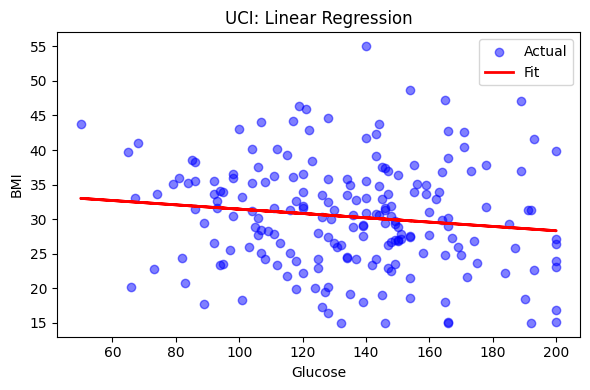

  Saved: linear_regression_UCI.png

Pima - Linear Regression (Glucose -> BMI)
  R2 Score   : 0.0001
  Coefficient: -0.0019
  Intercept  : 31.2299


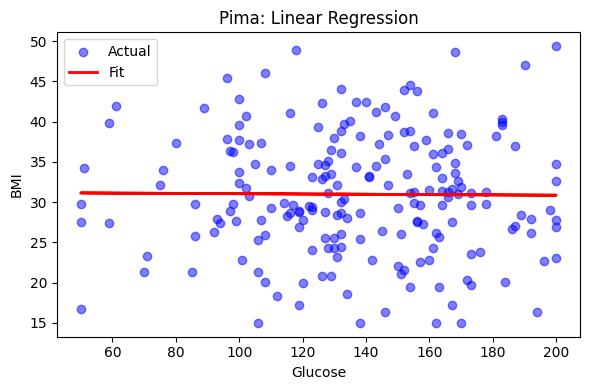

  Saved: linear_regression_Pima.png


Logistic Regression Results:
  UCI Accuracy: 0.4750
  Pima Accuracy: 0.6500


In [1]:
# EX.NO: 3B - Bivariate Analysis - Linear and Logistic Regression
# AIM: Apply linear and logistic regression on UCI and Pima Diabetes Datasets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score

np.random.seed(42)
n = 200

def gen_dataset(seed):
    np.random.seed(seed)
    return pd.DataFrame({
        'Glucose':       np.random.normal(137, 36, n).clip(50, 200).astype(int),
        'BloodPressure': np.random.normal(83, 19, n).clip(40, 130).astype(int),
        'BMI':           np.random.normal(31, 7.8, n).clip(15, 60),
        'Age':           np.random.randint(21, 80, n),
        'Outcome':       np.random.randint(0, 2, n)
    })

uci  = gen_dataset(42)
pima = gen_dataset(99)

# Linear Regression: Glucose -> BMI
for name, df in [("UCI", uci), ("Pima", pima)]:
    X = df[['Glucose']]
    y = df['BMI']
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    print(f"{name} - Linear Regression (Glucose -> BMI)")
    print(f"  R2 Score   : {r2:.4f}")
    print(f"  Coefficient: {model.coef_[0]:.4f}")
    print(f"  Intercept  : {model.intercept_:.4f}")

    plt.figure(figsize=(6, 4))
    plt.scatter(X, y, color='blue', alpha=0.5, label='Actual')
    plt.plot(X, y_pred, color='red', linewidth=2, label='Fit')
    plt.xlabel('Glucose'); plt.ylabel('BMI')
    plt.title(f'{name}: Linear Regression')
    plt.legend(); plt.tight_layout()
    plt.savefig(f'linear_regression_{name}.png')
    plt.show()
    print(f"  Saved: linear_regression_{name}.png\n")

# Logistic Regression: Predict Outcome
features = ['Glucose', 'BloodPressure', 'BMI', 'Age']
print("\nLogistic Regression Results:")
for name, df in [("UCI", uci), ("Pima", pima)]:
    X = df[features]; y = df['Outcome']
    Xt, Xte, yt, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LogisticRegression(max_iter=1000).fit(Xt, yt)
    acc = accuracy_score(yte, model.predict(Xte))
    print(f"  {name} Accuracy: {acc:.4f}")
